Simulated Annealing Plots

In [149]:
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [150]:
# Parameters
results_path = 'data/simulated_annealing/summary_2026-04-20_01-47-25.npy'
brute_force_data_directory = './data/brute_force/first_run' # use same as in cl_optimizer_experiments

In [151]:
import numpy as np

result_tensor = np.load(results_path)

In [152]:
result_tensor.shape # should be a 6-tuple: (n_problem_sizes, n_load_factors, n_instances_per_problem_size, n_runs_per_instance, n_temp_iter_steps, 2)

(19, 10, 10, 2, 8, 2)

In [162]:
loss_tensor = result_tensor[..., 1]
temp_iterations = result_tensor[0, 0, 0, 0, :, 0]

In [163]:
from pathlib import Path
import numpy as np
import pandas as pd
import re

extract_candidate_dimension = lambda p: np.log2(int(re.search(string=str(p.name), pattern=r'_(\d*)_candidates').group(1)))
extract_load_factor = lambda p: float(re.search(string=str(p.name), pattern=r'_(\d*\.\d*)_load_factor').group(1))

data_files = [p for p in Path(brute_force_data_directory).glob("*.csv") if p.is_file()]
candidate_dims = [(extract_candidate_dimension(p), extract_load_factor(p), p) for p in data_files]

df = pd.DataFrame(data=candidate_dims, columns=['dim', 'load factor', 'path'])
df = df.groupby(['dim', 'load factor'])['path'].agg(list).reset_index()

In [164]:
problem_sizes = df['dim'].unique()
load_factors = df['load factor'].unique()
brute_force_data_paths = np.array(df['path'].to_list(), dtype=object).reshape(len(problem_sizes), len(load_factors), -1)

problem_sizes = problem_sizes

In [165]:
import pandas as pd
import numpy as np
brute_force_data = np.vectorize(pd.read_csv)(brute_force_data_paths)
loss_spaces = [[np.array([d['loss'] for d in da]) for da in data] for data in brute_force_data] # needs to be list because is inhomogeneous

In [204]:
# RAAR | Temperature Iterations
# RAAR | Problem Size N
from metrics import raar

avg_loss_runs = loss_tensor.mean(axis=3)
raars = np.array([[[[raar(avg, loss_spaces[i][j][k, :]) for avg in avg_loss]for k, avg_loss in enumerate(avg_loss_runs_per_load_factor)] for j, avg_loss_runs_per_load_factor in enumerate(avg_loss_runs_per_problem_size)] for i, avg_loss_runs_per_problem_size in enumerate(avg_loss_runs)])

mean_raars_per_load_factor = raars.mean(axis=(0, 2))
std_raars_per_load_factor = raars.std(axis=(0, 2))

mean_raars = raars.mean(axis=(0, 1, 2))
std_raars = raars.std(axis=(0, 1, 2))

mean_raars_per_problem_size_and_load_factor = raars.mean(axis=(2, 3))
std_raars_per_problem_size_and_load_factor = raars.std(axis=(2, 3))

mean_raars_per_problem_size = raars.mean(axis=(1, 2, 3))
std_raars_per_problem_size = raars.std(axis=(1, 2, 3))

In [205]:
# Find optimal candidates to calculate TTS*
min_losses = np.array([[s.min(axis=1) for s in spaces] for spaces in loss_spaces])
optimal_candidates_found = np.count_nonzero(loss_tensor ==  np.expand_dims(np.expand_dims(min_losses, axis=-1), axis=-1), axis=3)
p_star = optimal_candidates_found / loss_tensor.shape[-2] # probability of finding optimal candidate

In [206]:
# TTS* | Problem Size N
from metrics import min_tts
tts_min = min_tts(p_star)

avg_min_tts_per_load_factor = tts_min.mean(axis=2)
std_min_tts_per_load_factor = np.nan_to_num(tts_min, posinf=0, neginf=0, nan=0).std(axis=2)

avg_min_tts = tts_min.mean(axis=(-1, 1))
std_min_tts = np.nan_to_num(tts_min, posinf=0, neginf=0, nan=0).std(axis=(-1, 1))

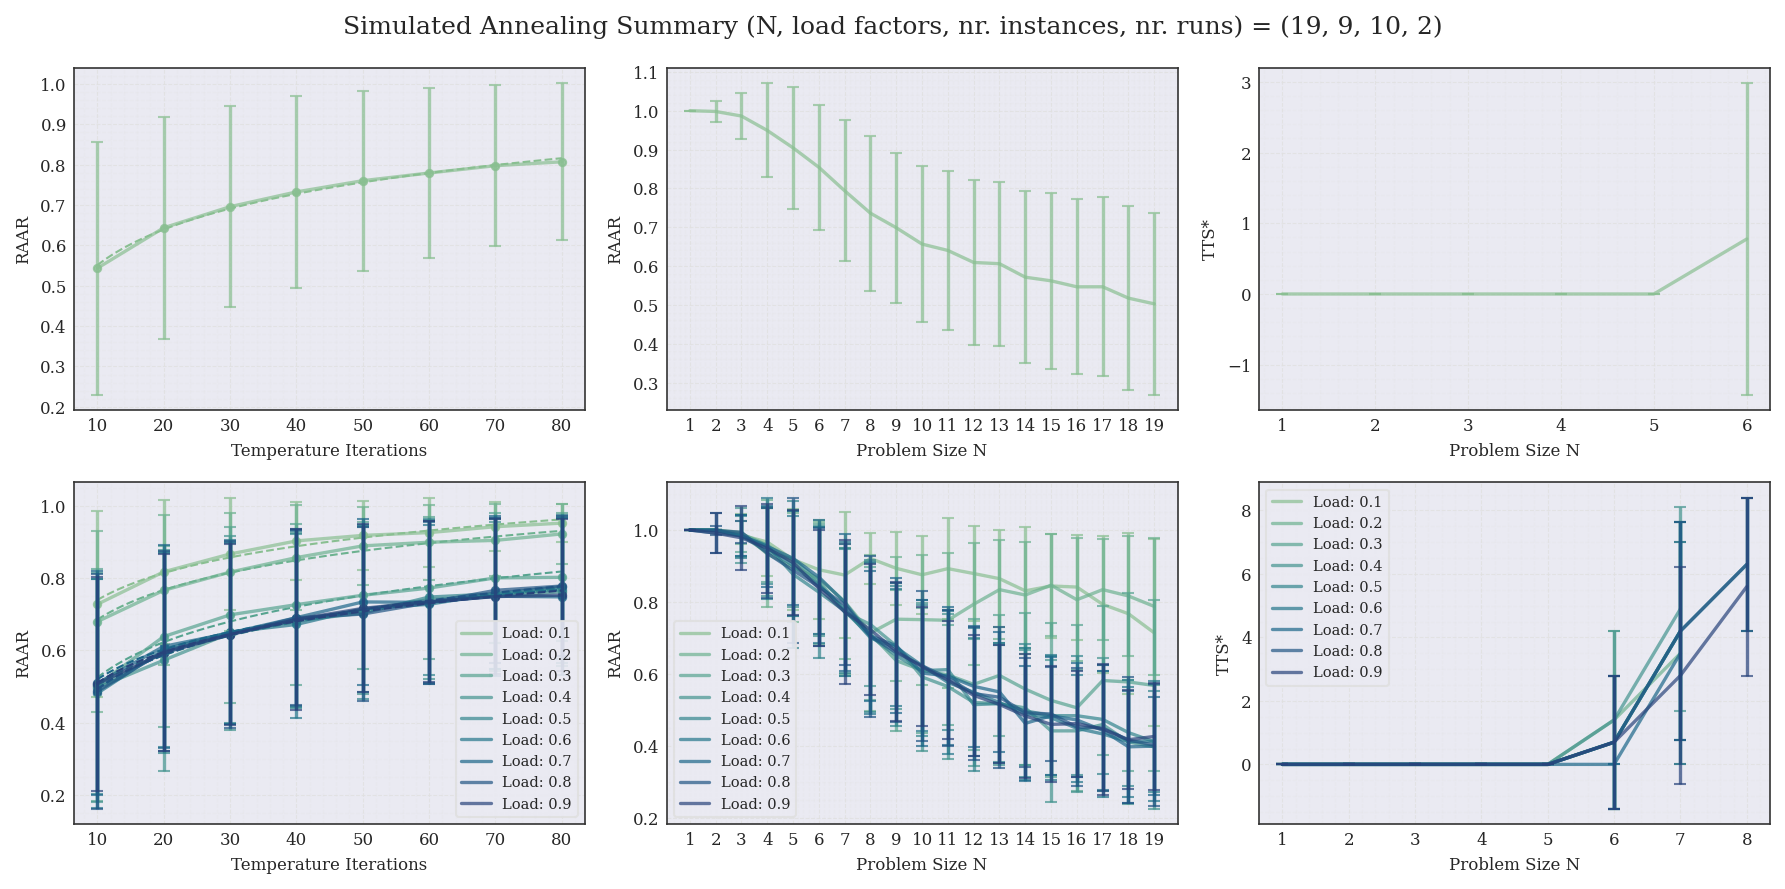

In [207]:
from datetime import datetime
import styling
import seaborn as sns

styling.set_my_style(use_latex=False)

palette = sns.color_palette("crest", len(load_factors))


fig, ax = styling.subplots(2, 3, figsize=(12, 6))
ax = ax.flatten()

fig.suptitle(f'Simulated Annealing Summary (N, load factors, nr. instances, nr. runs) = {loss_tensor.shape[0], loss_tensor.shape[1], loss_tensor.shape[2], loss_tensor.shape[3]}')

ax[0].set_xlabel('Temperature Iterations')
ax[0].set_ylabel('RAAR')
ax[0].plot(
    temp_iterations,
    mean_raars,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)


ax[0].errorbar(
    temp_iterations,
    mean_raars,
    yerr=std_raars,
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)

sns.regplot(x=temp_iterations, y=mean_raars, color=palette[0], ax=ax[0], line_kws={'linestyle': "--", 'linewidth': 1.0}, ci=None, logx=True)

ax[1].plot(
    problem_sizes,
    mean_raars_per_problem_size,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)

ax[1].set_xticks(problem_sizes)

ax[1].errorbar(
    problem_sizes,
    y=mean_raars_per_problem_size,
    yerr=std_raars_per_problem_size,
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)
ax[1].set_ylabel('RAAR')
ax[1].set_xlabel('Problem Size N')
ax[1].grid(visible=True)

ax[2].plot(
    problem_sizes,
    avg_min_tts,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)

ax[2].set_xticks(problem_sizes)

ax[2].errorbar(
    problem_sizes,
    y=avg_min_tts,
    yerr=std_min_tts,
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)
ax[2].set_ylabel('TTS*')
ax[2].set_xlabel('Problem Size N')
ax[2].grid(visible=True)

ax[3].set_xlabel('Temperature Iterations')
ax[3].set_ylabel('RAAR')
for i, (load_factor, mean_raar, std_raar) in enumerate(zip(load_factors, mean_raars_per_load_factor, std_raars_per_load_factor)):
    ax[3].plot(
        temp_iterations,
        mean_raar,
        alpha=0.7,
        linewidth=1.6,
        markersize=3.5,
        color=palette[i],
        label=f'Load: {load_factor}'
    )


    ax[3].errorbar(
        temp_iterations,
        mean_raar,
        yerr=std_raar,
        fmt="none",
        capsize=3,
        color=palette[i],
        alpha=0.7,
        linewidth=1.6
    )

    sns.regplot(x=temp_iterations, y=mean_raar, color=palette[i], ax=ax[3], line_kws={'linestyle': "--", 'linewidth': 1.0}, ci=None, logx=True)
ax[3].legend()


for i, (load_factor, mean_tts, std_pps) in enumerate(zip(load_factors, mean_raars_per_problem_size_and_load_factor.T, std_raars_per_problem_size_and_load_factor.T)):
    ax[4].plot(
        problem_sizes,
        mean_tts,
        alpha=0.7,
        linewidth=1.6,
        markersize=3.5,
        color=palette[i],
        label=f'Load: {load_factor}'
    )

    ax[4].set_xticks(problem_sizes)

    ax[4].errorbar(
        problem_sizes,
        y=mean_tts,
        yerr=std_pps,
        fmt="none",
        capsize=3,
        color=palette[i],
        alpha=0.7,
        linewidth=1.6
    )
ax[4].set_ylabel('RAAR')
ax[4].set_xlabel('Problem Size N')
ax[4].grid(visible=True)
ax[4].legend()


for i, (load_factor, mean, std) in enumerate(zip(load_factors, avg_min_tts_per_load_factor.T, std_min_tts_per_load_factor.T)):
    ax[5].plot(
        problem_sizes,
        mean,
        alpha=0.7,
        linewidth=1.6,
        markersize=3.5,
        color=palette[i],
        label=f'Load: {load_factor}'
    )

    ax[5].set_xticks(problem_sizes)

    ax[5].errorbar(
        problem_sizes,
        y=mean,
        yerr=std,
        fmt="none",
        capsize=3,
        color=palette[i],
        alpha=0.7,
        linewidth=1.6
    )
ax[5].set_ylabel('TTS*')
ax[5].set_xlabel('Problem Size N')
ax[5].grid(visible=True)
ax[5].legend()

plt.tight_layout()
plt.savefig(f'./plots/simulated_annealing_performance_summary_{datetime.now().strftime("%Y%m%d-%H%M%S")}.png')